<a href="https://colab.research.google.com/github/elenadaniels85-glitch/CUNY-Data-Analytics/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [105]:
#This data includes inspection results for active restaurants for the last few years
df = pd.read_csv("https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=300000")

/tmp/ipykernel_23971/2373476145.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=300000")


In [3]:
df.shape

(295616, 27)

In [4]:
df.head()

,camis,dba,boro,building,street,zipcode,phone,cuisine_description,inspection_date,action,...,inspection_type,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,location
0,50179767,CEDAR BROS CORP,Brooklyn,271,BAY RIDGE AVENUE,11220.0,6463397841,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.635912,-74.026590,310.0,47.0,6800.0,3145156.0,3.058620e+09,BK31,POINT (-74.026590008197 40.635912311744)
1,50169023,CAFE BON AMI,Manhattan,139,ORCHARD STREET,10002.0,2015395127,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.720034,-73.989260,103.0,1.0,1800.0,1088498.0,1.004150e+09,MN27,POINT (-73.989260331808 40.720034027074)
2,50182573,MAKO,Manhattan,424,5 AVENUE,10018.0,3124934694,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.751049,-73.982665,105.0,4.0,8400.0,1016004.0,1.008400e+09,MN17,POINT (-73.982664852255 40.751049055485)
3,50176082,Tacos Supreme,Bronx,2482,HOFFMAN STREET,10458.0,9177315718,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.857889,-73.886798,206.0,15.0,38900.0,2011942.0,2.030670e+09,BX06,POINT (-73.886798180947 40.857888765766)
4,50162803,MASTER PANDA,Manhattan,245,WEST 46 STREET,10036.0,9295056765,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.759204,-73.986536,105.0,3.0,12500.0,1024737.0,1.010180e+09,MN17,POINT (-73.986535905027 40.759204256088)


In [5]:
df.tail()

,camis,dba,boro,building,street,zipcode,phone,cuisine_description,inspection_date,action,...,inspection_type,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,location
295611,41060193,DUDLEY'S,Manhattan,85,ORCHARD STREET,10002.0,2129257355,Australian,2024-10-17T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.717866,-73.990375,103.0,1.0,1800.0,1005447.0,1.004130e+09,MN27,POINT (-73.990375378245 40.717865759507)
295612,50105989,THE RUSTY FACE,Brooklyn,188,GRAND STREET,11211.0,3473350006,Mediterranean,2023-03-15T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.714245,-73.960706,301.0,34.0,55100.0,3062792.0,3.023930e+09,BK73,POINT (-73.960706412943 40.714244571684)
295613,40943615,OTTO'S SHRUNKEN HEAD,Manhattan,538,EAST 14 STREET,10009.0,2122282240,Polynesian,2024-06-06T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.729760,-73.978810,103.0,2.0,3400.0,1005244.0,1.004070e+09,MN22,POINT (-73.978809770534 40.729760025178)
295614,50086385,$1 PIZZA,Manhattan,832,6 AVENUE,10001.0,9175878888,Pizza,2022-02-22T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.746510,-73.990158,105.0,3.0,7600.0,1015746.0,1.008300e+09,MN17,POINT (-73.990158293876 40.746510107881)
295615,50170936,% Arabica,Manhattan,30,ROCKEFELLER PLAZA,10112.0,5105041857,Coffee/Tea,2026-04-15T00:00:00.000,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Re-inspection,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295616 entries, 0 to 295615
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   camis                  295616 non-null  int64  
 1   dba                    295614 non-null  object 
 2   boro                   295616 non-null  object 
 3   building               294638 non-null  object 
 4   street                 295601 non-null  object 
 5   zipcode                292456 non-null  float64
 6   phone                  295535 non-null  object 
 7   cuisine_description    292082 non-null  object 
 8   inspection_date        295616 non-null  object 
 9   action                 292162 non-null  object 
 10  violation_code         289808 non-null  object 
 11  violation_description  289808 non-null  object 
 12  critical_flag          295616 non-null  object 
 13  score                  278615 non-null  float64
 14  grade                  145791 non-nu

In [12]:
#To keep only necessary columns
subset1 = df[['camis', 'boro', 'cuisine_description', 'inspection_date', 'violation_description', 'action', 'critical_flag', 'grade', 'grade_date']]

In [47]:
#To rename some columns for better understanding
subset1 = subset1.rename(columns={
    'camis': 'restaurant_id',
    'critical_flag': 'violation_class'
})

In [72]:
subset1. head()
#right away what catches my eye is that #1 place got critical violations and yet was given an A grade!!!
#maybe violations were corrected on the spot?

,restaurant_id,boro,cuisine_description,inspection_date,violation_description,action,violation_class,grade,grade_date
0,50179767,Brooklyn,NaN,1900-01-01T00:00:00.000,NaN,NaN,Not Applicable,NaN,NaN
1,50169023,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,NaN,Not Applicable,NaN,NaN
2,50182573,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,NaN,Not Applicable,NaN,NaN
3,50176082,Bronx,NaN,1900-01-01T00:00:00.000,NaN,NaN,Not Applicable,NaN,NaN
4,50162803,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,NaN,Not Applicable,NaN,NaN


In [73]:
subset1['boro'].unique()

array(['Brooklyn', 'Manhattan', 'Bronx', 'Queens', '0', 'Staten Island'],
      dtype=object)

In [74]:
#To exclude records where 'inspection_date' is '1900-01-01T00:00:00.000', i.e. where inspection has NOT yet been completed
#and where borough is not identified
subset2 = subset1[(subset1['inspection_date'] != '1900-01-01T00:00:00.000') & (subset1['boro'] != '0')]
subset2.shape

(291867, 9)

In [75]:
#To drop the timestamp and keep only the date for inspection_date variable
#First, convert the object type to datetime
subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date'])
subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date']).dt.normalize()
subset2['inspection_date'].info()

<class 'pandas.core.series.Series'>
Index: 291867 entries, 6 to 295615
Series name: inspection_date
Non-Null Count   Dtype         
--------------   -----         
291867 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 4.5 MB


/tmp/ipykernel_23971/1697290084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date'])
/tmp/ipykernel_23971/1697290084.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date']).dt.normalize()


In [76]:
subset2['inspection_date']

,inspection_date
6,2025-05-27
9,2023-05-02
11,2024-10-30
18,2025-05-28
28,2026-03-10
...,...
295611,2024-10-17
295612,2023-03-15
295613,2024-06-06
295614,2022-02-22


In [77]:
#to extract year into a separate column
subset2['inspection_year'] = subset2['inspection_date'].dt.year
subset2.head(20)

/tmp/ipykernel_23971/1508031764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_year'] = subset2['inspection_date'].dt.year


,restaurant_id,boro,cuisine_description,inspection_date,violation_description,action,violation_class,grade,grade_date,inspection_year
6,40387418,Manhattan,Bagels/Pretzels,2025-05-27,Hot TCS food item not held at or above 140 °F.,Violations were cited in the following area(s).,Critical,NaN,NaN,2025
9,40741728,Manhattan,Continental,2023-05-02,Hot TCS food item not held at or above 140 °F.,Violations were cited in the following area(s).,Critical,NaN,NaN,2023
11,41701450,Queens,Sandwiches,2024-10-30,NaN,No violations were recorded at the time of thi...,Not Applicable,A,2024-10-30T00:00:00.000,2024
18,50131935,Queens,American,2025-05-28,"Sanitized equipment or utensil, including in-u...",Violations were cited in the following area(s).,Critical,A,2025-05-28T00:00:00.000,2025
28,50064940,Queens,"Juice, Smoothies, Fruit Salads",2026-03-10,"Wiping cloths not stored clean and dry, or in ...",Violations were cited in the following area(s).,Critical,A,2026-03-10T00:00:00.000,2026
36,50001854,Manhattan,Donuts,2023-03-21,Evidence of rats or live rats in establishment...,Violations were cited in the following area(s).,Critical,A,2023-03-21T00:00:00.000,2023
39,41053236,Manhattan,American,2025-06-07,NaN,No violations were recorded at the time of thi...,Not Applicable,NaN,NaN,2025
45,50106949,Manhattan,Caribbean,2023-01-03,Hot TCS food item not held at or above 140 °F.,Violations were cited in the following area(s).,Critical,NaN,NaN,2023
51,50098716,Manhattan,Pizza,2024-06-14,NaN,Establishment re-opened by DOHMH.,Not Applicable,P,2024-06-14T00:00:00.000,2024
94,50046567,Bronx,Coffee/Tea,2024-09-08,NaN,No violations were recorded at the time of thi...,Not Applicable,NaN,NaN,2024


<Axes: xlabel='inspection_year'>

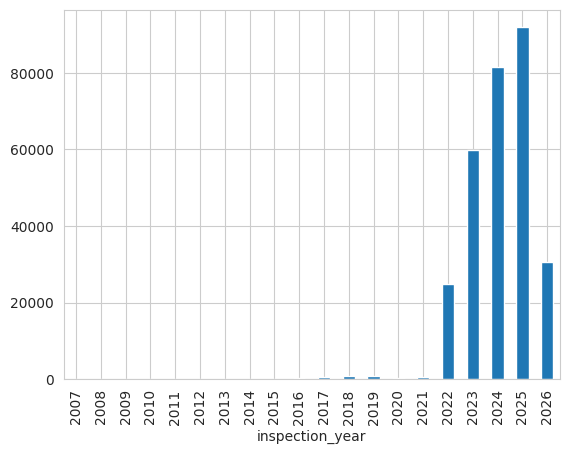

In [78]:
#to return how many inspections conducted per year
year_counts = subset2.groupby(subset2['inspection_year']).size()
year_counts.plot(kind='bar')

In [79]:
#to focus only on the last 3 years (as these years appear to have most complete data) - remove all years other than 2023, 2024, 2025
subset3 = subset2[subset2['inspection_year'].isin([2023, 2024, 2025])]

In [80]:
#how many unique restaurant ID's in the data set - this is how many restaurants were inspected over last 3 subject years
subset3['restaurant_id'].nunique()

25877

In [81]:
subset3['cuisine_description'].unique()

array(['Bagels/Pretzels', 'Continental', 'Sandwiches', 'American',
       'Donuts', 'Caribbean', 'Pizza', 'Coffee/Tea', 'Japanese', 'Thai',
       'French', 'Italian', 'Latin American', 'Middle Eastern',
       'Mediterranean', 'Asian/Asian Fusion', 'Mexican', 'Peruvian',
       'Jewish/Kosher', 'Chinese', 'Bottled Beverages', 'Spanish',
       'Bakery Products/Desserts', 'Indian', 'Turkish', 'Soul Food',
       'Chicken', 'Salads', 'New American', 'Korean', 'Ethiopian',
       'Other', 'Pancakes/Waffles', 'Eastern European', 'Brazilian',
       'Fusion', 'Frozen Desserts', 'Pakistani', 'Seafood',
       'Juice, Smoothies, Fruit Salads', 'Southeast Asian', 'Creole',
       'Steakhouse', 'Tex-Mex', 'Bangladeshi', 'Polish', 'Hotdogs',
       'Afghan', 'Irish', 'German', 'Sandwiches/Salads/Mixed Buffet',
       'Tapas', 'Greek', 'Hamburgers', 'Barbecue', 'Filipino', 'African',
       'New French', 'Cajun', 'Vegetarian', 'Hotdogs/Pretzels',
       'Australian', 'Russian', 'Iranian', 'Not L

In [82]:
#How many different cuisines - reveals how many cuisines NYC has to offer - about 90 - we are really spoiled!
subset3['cuisine_description'].nunique()

90

<Axes: ylabel='proportion'>

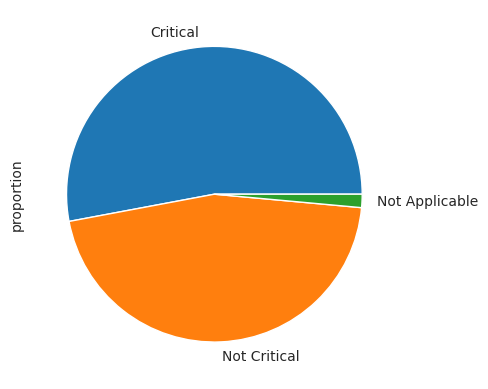

In [83]:
#critical violations are those most likely to contribute to foodborne illness, i.e. food poisoniing
#this pie chart shows the count as a percentage of the total
critical_percentages = (subset3['violation_class'].value_counts(normalize=True) * 100)
critical_percentages.plot(kind='pie')
#Insight: isntances where no violations were cited at the time of inspection are very rare!
#I think it is safe to say (but maybe not safe to eat))) any time you enjoy your food at or from a restaurant of any kind, there is a 50-50
#chance that that restaurant has critical violations which by definition may lead to you getting food poisoning

In [84]:
# A few examples of critical_class violtions: Live roaches in facility's food or non-food area, Hot food item not maintained at proper temperature,
#Evidence of rats or live rats in establishment.

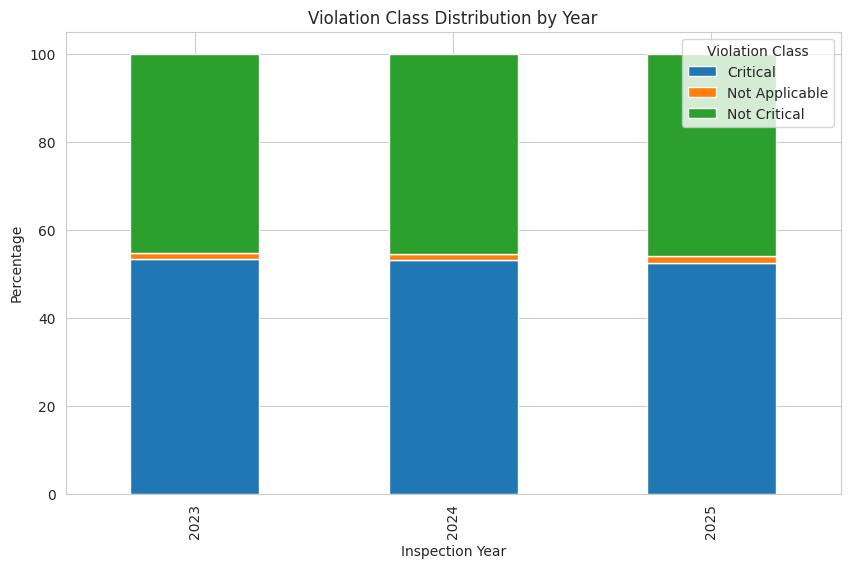

In [136]:
#to create a stacked bar by year and violation_class

yearly_pct = (
    subset3
    .groupby(['inspection_year', 'violation_class'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
)

sns.set_style("whitegrid")

yearly_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.ylabel('Percentage')
plt.xlabel('Inspection Year')
plt.title('Violation Class Distribution by Year')
plt.legend(title='Violation Class')
plt.show()

#Insigt, the ratios by violation class are shown to be consisten over the subject years

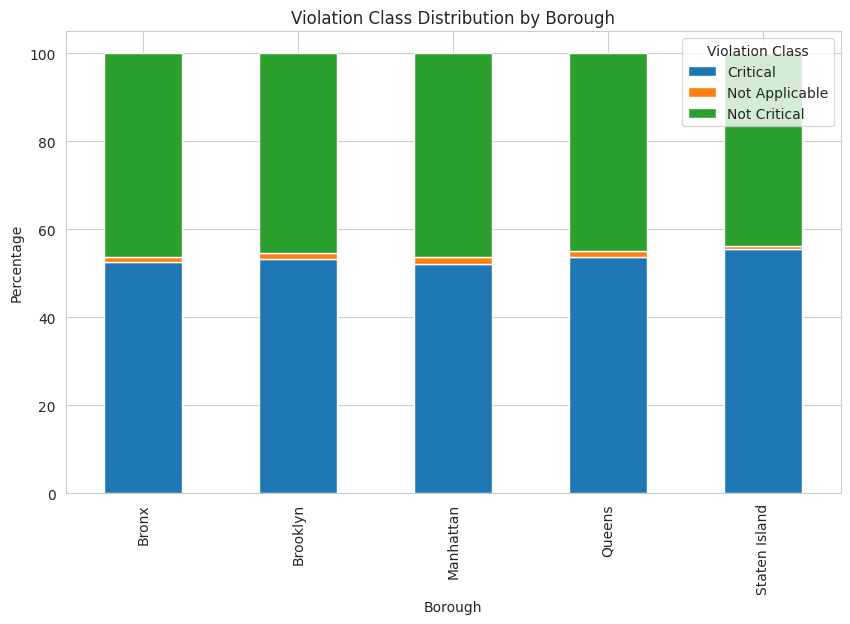

In [132]:
#aggreage by boro

boro_pct = (
    subset3
    .groupby(['boro', 'violation_class'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
)

sns.set_style("whitegrid")

boro_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.ylabel('Percentage')
plt.xlabel('Borough')
plt.title('Violation Class Distribution by Borough')
plt.legend(title='Violation Class')
plt.show()

#insight - violation class rations are also consistent among boroughs  so we can't really say that it is safer to eat in Brooklyn

In [94]:
#would like to return the top 10 cuisines with the lowest rate of critical violations -the safest cuisine!
#1st step: Calculate critical violation rate per cuisine
cuisine_rates = (
    subset3
    .groupby('cuisine_description')['violation_class']
    .apply(lambda x: (x == 'Critical').mean() * 100)
    .reset_index(name='critical_rate')
)

In [95]:
#step 2: filter by minimum inspections (more than 10)
#This avoids something like:
#Cuisine A → 1 inspection, 0 critical → looks “perfect” (misleading)
counts = subset3['cuisine_description'].value_counts()
cuisine_rates = cuisine_rates[
    cuisine_rates['cuisine_description'].isin(counts[counts >= 10].index)
]

In [96]:
top10_lowest = cuisine_rates.sort_values('critical_rate').head(10)

print(top10_lowest)

        cuisine_description  critical_rate
62       Nuts/Confectionary      26.666667
46                  Iranian      40.540541
39               Hamburgers      45.033304
14              Californian      45.112782
35        Fruits/Vegetables      45.454545
42                  Hotdogs      45.505618
72                   Salads      45.910290
85                  Tex-Mex      45.928753
79  Soups/Salads/Sandwiches      46.105919
27                   Donuts      46.798744


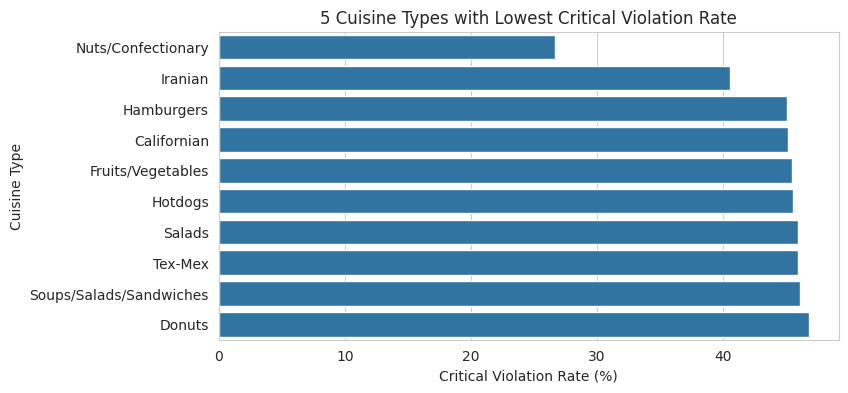

In [97]:
#to visualize
plt.figure(figsize=(8,4))

sns.barplot(
    data=top10_lowest,
    x='critical_rate',
    y='cuisine_description'
)

plt.title('5 Cuisine Types with Lowest Critical Violation Rate')
plt.xlabel('Critical Violation Rate (%)')
plt.ylabel('Cuisine Type')

plt.show()

#looks like it is best to go for nuts and candy when you are hungry!

In [110]:
subset3.shape

(232968, 10)

In [106]:
#group by grade
subset3.groupby(['grade']).size()

,0
grade,
A,78656
B,16305
C,12035
N,5823
P,694
Z,1981


In [127]:
#to filter out any records where the grade are pending (i.e N, P, or Z ) and violation class is other than critical
subset4 = subset3[((subset3['grade'] == 'A') | (subset3['grade'] == 'B') | (subset3['grade'] == 'C')) & (subset3["violation_class"] == 'Critical')]
subset4.shape

#far from every inspection results in a grade

(52959, 10)

In [128]:
#group by grade and violation class
subset4.groupby(['grade', 'violation_class']).size()

,,0
grade,violation_class,
A,Critical,35089
B,Critical,10133
C,Critical,7737


In [129]:
#this does not make sense
# for example, 50143076	Queens	Continental	2024-02-07T00:00:00.000	Hot TCS food item not held at or above 140 °F.
#Violations were cited in the following area(s).	Critical	A	2024-02-07T00:00:00.000
#this establishement received grade A on the same day as it was cited a critical violation!

#I would like to see how many A grades had a critical and non-critical violations cited by rate

/tmp/ipykernel_23971/4186489692.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=grade_plot, x='grade', y='count', hue='violation_class', palette=['red', 'red'] )


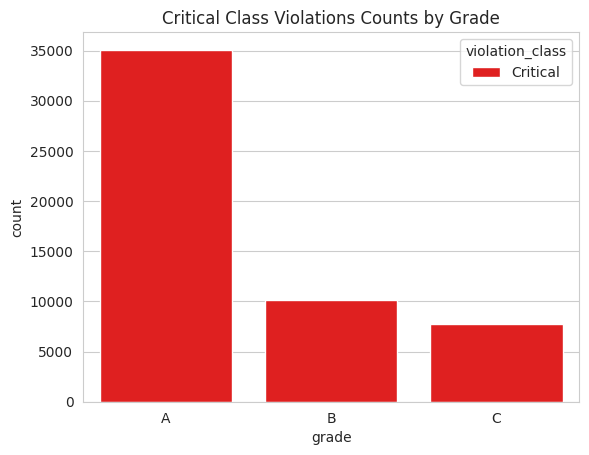

In [131]:
# Count the sizes and reset index to turn Series into DataFrame
grade_plot = subset4.groupby(['grade', 'violation_class']).size().reset_index(name='count')

# Create the grouped bar plot
sns.barplot(data=grade_plot, x='grade', y='count', hue='violation_class', palette=['red', 'red'] )
plt.title('Critical Class Violations Counts by Grade')
plt.show()

#Insight: this is a very disturbing finding - grade A restaurants have the highest number of critical violaitons!
#FYI: Dates when grades are issued seem to be matching the dates that violations are cited!
#Beware consumer! Grades are highly subjective!